<a href="https://colab.research.google.com/github/AlokDhanush/cat_vs_dog/blob/main/CatvsDog.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Import neccessary libraries
import os
import numpy as np
from skimage.transform import resize
from skimage.io import imread
import matplotlib.pyplot as plt

In [ ]:
train_data = os.listdir("Path_to_the_folder_containing_training_images")#Source path for training set

images = [] #To store image resized data
flat_data = [] #To store the flattened image data
target = [] #To store labels values ['0' = Cat, '1' = Dog]

CATEGORIES = ['cat', 'dog'] #Labels

for category in train_data:
  count = 0
  if category != "classname.txt": #Change it based on your training and testing folders
    class_num = CATEGORIES.index(category)
    source_path = os.path.join("Path_to_the_folder_containing_training_images", category)
    for img in os.listdir(source_path):
      path = os.path.join(source_path, img)
      target.append(class_num)
      img = imread(path)
      img_resized = resize(img, (200, 200, 3))
      flat_data.append(img_resized.flatten())
      images.append(img_resized)
      count += 1
      if count == 95: #Selecting and converting only 95 images from cat and dog images respectively
        break


#Converting all the lists into numpy array
flat_data = np.array(flat_data)
target = np.array(target)
images = np.array(images)

In [ ]:
flat_data[:2]

array([[0.01064563, 0.01064563, 0.01064563, ..., 0.03518316, 0.01746493,
        0.02748657],
       [0.40403207, 0.41579677, 0.34913011, ..., 0.39156906, 0.39723317,
        0.43455977]])

In [ ]:
np.unique(target, return_counts=True)

(array([0, 1]), array([95, 95]))

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split

#Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(flat_data, target, shuffle = True, test_size=0.25, stratify = target)

In [ ]:
#Param_grid contains some values for 'C' and 'gamma' for the best values selection
param_grid = [
    {'C': [1, 10, 1000], 'gamma':[0.01, 0.001, 0.0001]}
]

svc = SVC()   ##SVC model
model = GridSearchCV(svc, param_grid) ##GridSearchCV to find the best 'C' and 'gamma' in the given list of values
model.fit(X_train, y_train)

GridSearchCV(estimator=SVC(),
             param_grid=[{'C': [1, 10, 1000], 'gamma': [0.01, 0.001, 0.0001]}])

In [ ]:
best_model = model.best_estimator_

In [ ]:
model.best_params_

{'C': 10, 'gamma': 0.0001}

In [ ]:
#Testing accuracy of the model
from sklearn.metrics import accuracy_score, confusion_matrix

y_pred = best_model.predict(X_test)
accuracy_score(y_pred, y_test)

0.625

In [ ]:
y_pred, y_test

(array([0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1,
        0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1,
        1, 0, 1, 1]),
 array([1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1,
        1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1,
        1, 0, 1, 1]))

In [ ]:
val_data = os.listdir("Path_to_the_folder_containing_validation_images") #Source path for validation set
actual = [] #To store the actual labels
flat_data_val = [] #To store flat data

for category in val_data:
  if category != "classname.txt":
    path = os.path.join("Path_to_the_folder_containing_validation_images", category)
    for img in os.listdir(path):
      img = imread(os.path.join(path, img))
      img_resized = resize(img, (200, 200, 3))
      actual.append(CATEGORIES.index(category))
      flat_val = img_resized.flatten()
      flat_data_val.append(flat_val)


In [ ]:
#Convert to numpy array
actual = np.array(actual)
flat_data_val = np.array(flat_data_val)

y_pred_val = best_model.predict(flat_data_val)
#Find the accuracy
accuracy_score(y_pred_val, actual)

0.5285714285714286

###Classification of online images

In [ ]:
#Saving model using Pickle
import pickle

pickle.dump(model, open('img_model.p', 'wb'))

Enter your url: https://cdn.shopify.com/s/files/1/1708/4041/files/custom_resized_lab_600x600.jpg?v=1668581125


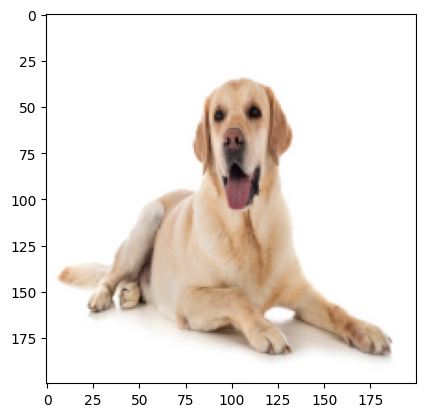

Predicted output: cat
Predicted class: [0]


In [ ]:
url = input("Enter your url: ")
img = imread(url)
img_resized = resize(img, (200, 200, 3))
img_flat = img_resized.flatten()
plt.imshow(img_resized)
plt.show()
y_pred = best_model.predict([img_flat])
print(f"Predicted output: {CATEGORIES[y_pred[0]]}")
print(f"Predicted class: {y_pred}")

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers

In [ ]:
X_train = X_train.reshape(-1, 200, 200, 3)
X_test = X_test.reshape(-1, 200, 200, 3)

flat_data_val = flat_data_val.reshape(-1, 200, 200, 3)

In [ ]:
X_train.shape, flat_data_val.shape

((142, 200, 200, 3), (70, 200, 200, 3))

In [ ]:
##Tensorflow model for classsification

catvsdog_model = tf.keras.Sequential([
    layers.Conv2D(input_shape=(200,200,3), kernel_size=(3,3), strides=(2,2), padding="same", filters=64),
    layers.MaxPooling2D(pool_size=(3,3), strides=(1,1), padding="same"),
    layers.Conv2D(kernel_size =(3,3), padding="same", strides=(2,2), filters=64),
    layers.MaxPooling2D(pool_size=(3,3), strides=(1,1), padding="same"),
    layers.Conv2D(kernel_size =(3,3), padding="same", strides=(2,2), filters=64),
    layers.MaxPooling2D(pool_size=(3,3), strides=(1,1), padding="same"),

    layers.Flatten(),
    layers.Dense(256, activation="relu"),
    layers.Dense(128, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])


catvsdog_model.compile(optimizer="adam", loss=tf.keras.losses.BinaryCrossentropy(), metrics=["accuracy"])

In [ ]:
#Optimizatin techniques to overcome 'Overfitting' during training
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=0.001)


catvsdog_model.fit(X_train, y_train, epochs=30, validation_data=(flat_data_val, actual), callbacks=[ reduce_lr])

Epoch 1/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 442ms/step - accuracy: 0.4672 - loss: 1.1322 - val_accuracy: 0.6571 - val_loss: 0.6995 - learning_rate: 0.0010
Epoch 2/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - accuracy: 0.5891 - loss: 0.8364 - val_accuracy: 0.6571 - val_loss: 0.6935 - learning_rate: 0.0010
Epoch 3/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.4374 - loss: 0.8495 - val_accuracy: 0.6571 - val_loss: 1.0171 - learning_rate: 0.0010
Epoch 4/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.5972 - loss: 0.8675 - val_accuracy: 0.6714 - val_loss: 0.6605 - learning_rate: 0.0010
Epoch 5/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.6089 - loss: 0.6375 - val_accuracy: 0.6714 - val_loss: 0.6537 - learning_rate: 0.0010
Epoch 6/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.6067 - loss: 0.6118 - val_accuracy: 0.6857 - val_loss: 0.6914 - learning_rate: 0.0010
Epoch 7/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.6138 - loss: 0.6258 - val_accuracy: 0.4857

Enter your url: https://i.natgeofe.com/n/548467d8-c5f1-4551-9f58-6817a8d2c45e/NationalGeographic_2572187_3x4.jpg


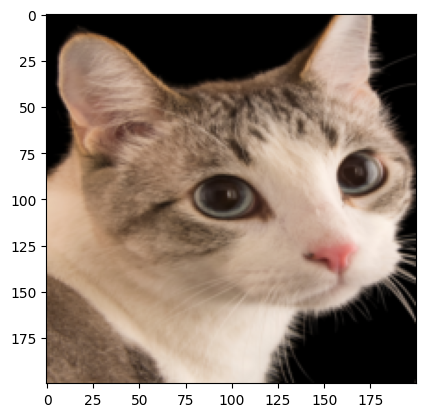

(1, 200, 200, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Predicted output: Dog
Confidence: 0.8279879689216614


In [ ]:
url = input("Enter your url: ")
img = imread(url)
img_resized = resize(img, (200, 200, 3))
plt.imshow(img_resized)
plt.show()
img_resized = img_resized.reshape(-1, 200, 200, 3)
print(img_resized.shape)
y_pred = catvsdog_model.predict(img_resized)
output = "Dog" if y_pred[0][0] > 0.5 else "Cat"
print(f"Predicted output: {output}")
if y_pred[0][0] < 0.5:
  print(f"Confidence: {1 - y_pred[0][0]}")
else:
  print(f"Confidence: {y_pred[0][0]}")

In [ ]:
import pickle

pickle.dump(catvsdog_model, open('catvsdog_model.p', 'wb'))

###Model deployment using streamlit

In [ ]:
!pip install streamlit

In [ ]:
!pip install pyngrok

from pyngrok import ngrok

!ngrok config add-authtoken your_ngrok_authtoken

In [ ]:
%%writefile catvsdog.py

import streamlit as st
import numpy as np
from skimage.io import imread
from skimage.transform import resize
from PIL import Image
import pickle

st.title("Image Classification")
st.text('Upload the image')

catvsdog_model = pickle.load(open('catvsdog_model.p', 'rb'))

uploaded_file = st.file_uploader("Choose an image...", type = "jpg")

if uploaded_file is not None:
  img = Image.open(uploaded_file)
  st.image(img, caption = 'Uploaded Image')

  if st.button('PREDICT'):
    st.write('Result:- ')
    img = np.array(img)
    img_resized = resize(img, (150, 150, 3))
    img_resized = img_resized.reshape(-1, 150, 150, 3)
    y_pred = catvsdog_model.predict(img_resized)
    if y_pred[0][0] > 0.5:
      st.title("Predicted Output:- Dog")
    else:
      st.title("Predicted Output:- Cat")


In [ ]:
!pip install pyngrok

In [ ]:
from pyngrok import ngrok

# Replace 'your_authtoken' with your actual ngrok authtoken
ngrok.set_auth_token("your_ngrok_authtoken")

In [ ]:
from pyngrok import ngrok

# Open a tunnel on port 8501
http_tunnel = ngrok.connect(8501)

# Print the public URL
print("Public URL:", http_tunnel.public_url)